# Paradigm influence on resting-state FC estimates

In [1]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

Loading required package: lpSolve



## Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030). We first load the FC matrices from the generalization protocol, extract the scanner used and keep only the ones scanned on the Prisma. Secondly, we load the FC matrices from the reliability protocol and concatenate the dataframes.

In [2]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths

# Define filtering parameters
metric = "sparseinversecovariance"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)       
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

## Load files corresponding to the generalization sessions
entities_base = {
    "subject": "001",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}
entities_base_gen = {
    **entities_base,
    "task": "rest",
}
# Get functional connectivity files
files_gen = layout.get(**entities_base_gen, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_gen) == 36, f"Expected 36 FC matrices, got {len(files_gen)}"
df_fc = pd.DataFrame({"filename": files_gen, "task": "rest", "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)

# Keep only the session with prisma scanner
df_fc = df_fc[df_fc["scanner"] == "prisma"]
df_fc = df_fc.drop(columns=["scanner"])
assert len(df_fc) == 12, f"Expected 12 FC matrices for prisma scanner, got {len(df_fc)}"

## Load files corresponding to the reliability sessions
entities_base_rel = {
    **entities_base,
    "task": "rsmovie",
}
# Get functional connectivity files
files_rel = layout.get(**entities_base_rel, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_rel) == 36, f"Expected 36 FC matrices, got {len(files_rel)}"
df_fc_rel = pd.DataFrame({"filename": files_rel, "task": "rsmovie", "subject": "001"})
df_fc_rel["session"] = df_fc_rel["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)
df_fc_rel["repetition"] = df_fc_rel.index + 1

## Concatenate the two dataframes
df_fc = pd.concat([df_fc, df_fc_rel], ignore_index=True)
assert len(df_fc) == 48, f"Expected 48 FC matrices after concatenation, got {len(df_fc)}"
')

In [3]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
head(df_fc)

,filename,task,subject,session,repetition
,<chr>,<chr>,<chr>,<chr>,<dbl>
1,/data/derivatives/hcph-fc/sub-001/ses-20101060/func/sub-001_ses-20101060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20101060,1
2,/data/derivatives/hcph-fc/sub-001/ses-20201060/func/sub-001_ses-20201060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20201060,2
3,/data/derivatives/hcph-fc/sub-001/ses-20301060/func/sub-001_ses-20301060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20301060,3
4,/data/derivatives/hcph-fc/sub-001/ses-20402060/func/sub-001_ses-20402060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20402060,4
5,/data/derivatives/hcph-fc/sub-001/ses-20502060/func/sub-001_ses-20502060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20502060,5
6,/data/derivatives/hcph-fc/sub-001/ses-20601060/func/sub-001_ses-20601060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20601060,6


## Intra-class correlation coefficient (ICC) to quantify intra-scanner reliability

Let's quantify the intra-scanner reliability of FC estimates when using our naturalistic movie for resting-state.

In [16]:
icc_results <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), stringsAsFactors = FALSE)

df_rsmovie <- df_fc[df_fc$task == "rsmovie", ]
df_rsmovie <- t(df_rsmovie[, edge_keys])
head(df_rsmovie)
icc_val <- icc(df_rsmovie, model = "twoway", type = "agreement", unit = "single")$value
cat(sprintf("ICC for rsmovie: %.4f\n", icc_val))
icc_results <- rbind(icc_results, data.frame(variability_type = "within-scanner", task = "rsmovie", scanner = "prisma", repetition = NA, ICC = icc_val, summary_statistic = NA))

,13,14,15,16,17,18,19,20,21,22,⋯,39,40,41,42,43,44,45,46,47,48
edge1,1.102220e-06,6.415947e-06,-4.595372e-06,3.259803e-06,1.441370e-05,7.021473e-06,-1.020239e-06,5.842345e-05,-7.386642e-07,-1.819866e-06,⋯,1.427782e-07,1.067174e-06,-4.284423e-06,-1.063658e-05,-6.137563e-06,-4.678330e-06,-4.588838e-07,-5.199323e-06,-1.930210e-06,1.125792e-06
edge2,-7.794015e-07,-6.468752e-07,-2.194737e-06,-6.716801e-07,6.054336e-06,2.366883e-06,1.464118e-07,1.635985e-04,3.472887e-06,-1.046269e-07,⋯,-2.036710e-07,9.921960e-08,-3.770929e-06,3.638309e-02,-7.807891e-06,1.433800e-02,-4.062786e-07,1.576103e-02,5.235316e-02,6.780837e-06
edge3,1.139434e-05,5.280384e-06,-8.793063e-06,5.543463e-03,1.137742e-05,5.896386e-02,-1.159955e-06,4.520909e-05,-1.051122e-06,-7.542363e-06,⋯,-2.609990e-06,-2.594676e-06,-5.589937e-06,2.233237e-02,1.421963e-01,-1.567289e-05,-2.738721e-06,9.256322e-06,-1.077018e-05,5.888299e-07
edge4,-2.108473e-05,3.844471e-02,6.452152e-02,3.652434e-02,5.151805e-02,2.030996e-05,4.823714e-02,8.268471e-02,4.989634e-02,5.762318e-02,⋯,4.310278e-02,4.568402e-02,2.367034e-05,-3.039112e-05,-2.870628e-05,7.280732e-06,-5.724659e-06,-2.320633e-06,-1.551173e-06,9.287778e-06
edge5,-5.255465e-07,1.069534e-06,-1.941939e-06,1.990934e-07,6.011015e-06,-1.473689e-07,-4.917529e-07,1.050275e-04,2.452045e-07,-9.815775e-07,⋯,-1.558604e-07,3.366410e-07,-3.251314e-06,3.433093e-06,1.607545e-07,-1.188681e-06,1.352869e-07,1.584268e-08,1.891379e-07,-1.540721e-06
edge6,-6.066261e-06,4.212206e-07,-4.056693e-06,-7.268224e-07,5.638678e-06,1.130457e-06,-5.580014e-08,2.000679e-04,-1.388992e-07,-1.986019e-08,⋯,-2.985605e-07,8.313284e-08,-2.428235e-06,2.739582e-06,-3.661786e-06,6.245403e-06,-4.533894e-08,-4.280846e-07,5.141747e-07,5.194488e-06


ICC for rsmovie: 0.8726


## ICC to quantify variability across paradigms

In [15]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Randomly select 12 sessions from the rsmovie task because we need to have the same number of sessions for each task to be able to compute ICC
selected_sessions <- sample(unique(df_fc$repetition[df_fc$task == "rsmovie"]), 12)
df_paradigm <- df_fc[df_fc$repetition %in% selected_sessions | df_fc$task == "rest", ]

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_paradigm[, c( "task", edge)]
    df_icc <- pivot_wider(df_icc, names_from = task, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(rest, rsmovie))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
df_icc
head(icc_vals)


rest,rsmovie
<dbl>,<dbl>
5.167582e-17,1.504906e-17
-3.850324e-17,8.938102e-17
1.681766e-17,6.357596e-03
-1.098919e-16,-3.064470e-16
1.035807e-02,8.454763e-17
-7.349301e-17,4.316731e-17
-3.314509e-17,1.160874e-16
3.888169e-02,1.588796e-02
7.479356e-17,2.059626e-16


,edge,ICC
,<chr>,<dbl>
1,edge1,0.26062320
2,edge2,-0.05622526
3,edge3,0.67556929
4,edge4,-0.37011832
5,edge5,0.45176637
6,edge6,0.13564714


Mean ICC across edges: 0.03365581 
Median ICC across edges: 0.8725827 


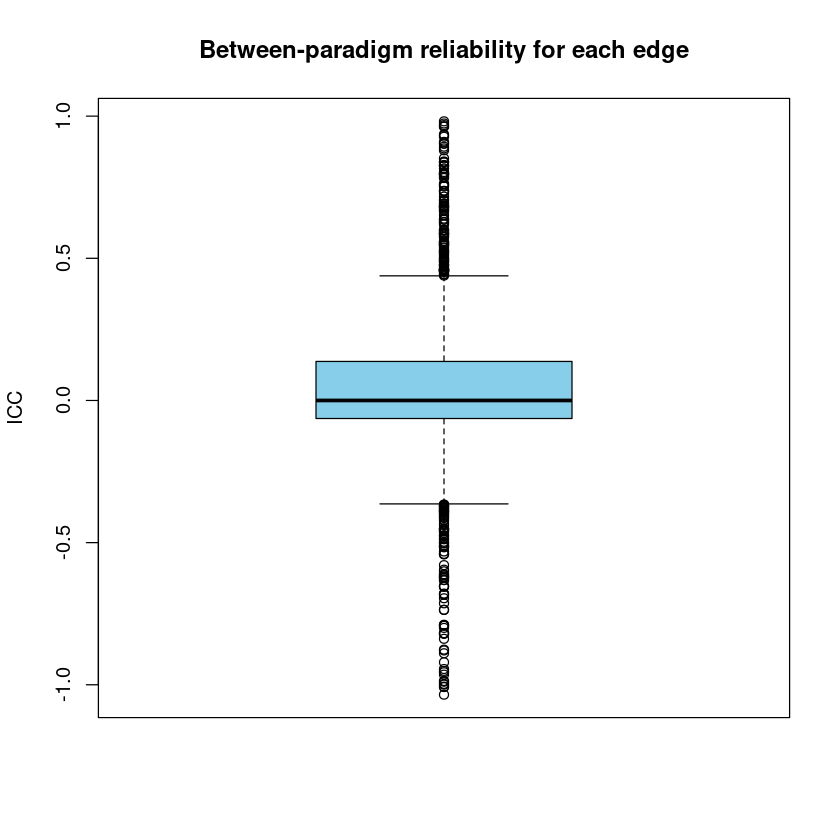

In [18]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_results$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")

In [19]:
# Reset the repetition values for rsmovie sessions to the range 1 to 12 so we can perform the pairing with rest sessions
df_paradigm$repetition[df_paradigm$task == "rsmovie"] <- as.factor(rep(1:12, each = nrow(df_paradigm[df_paradigm$task == "rsmovie", ]) / 12))

for (rep in unique(df_paradigm$repetition)) {
    df_rep <- df_paradigm[df_paradigm$repetition == rep, ]
    colnames <- df_rep$task
    df_rep <- t(df_rep[, edge_keys])
    colnames(df_rep) <- colnames
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
    icc_results <- rbind(icc_results, data.frame(variability_type = "between-paradigm", task=NA, scanner="prisma", repetition = rep, ICC = icc_val, summary_statistic = NA))
}
head(df_rep)
icc_results

,rest,rsmovie
edge1,-1.738165e-06,1.125792e-06
edge2,-1.091652e-06,6.780837e-06
edge3,1.356319e-05,5.888299e-07
edge4,6.414071e-02,9.287778e-06
edge5,4.221924e-07,-1.540721e-06
edge6,3.592163e-07,5.194488e-06


variability_type,task,scanner,repetition,ICC,summary_statistic
<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>
within-scanner,rsmovie,prisma,NA,0.8725827,NA
between-paradigm,NA,prisma,1,0.6526815,NA
between-paradigm,NA,prisma,2,0.7569532,NA
between-paradigm,NA,prisma,3,0.7377676,NA
between-paradigm,NA,prisma,4,0.8091292,NA
between-paradigm,NA,prisma,5,0.8084433,NA
between-paradigm,NA,prisma,6,0.7057181,NA
between-paradigm,NA,prisma,7,0.8554978,NA
between-paradigm,NA,prisma,8,0.8210733,NA


Mean ICC across edges: 0.7903209 
Quantiles (25%, median, 75%): 0.7569532 0.8084433 0.841585 


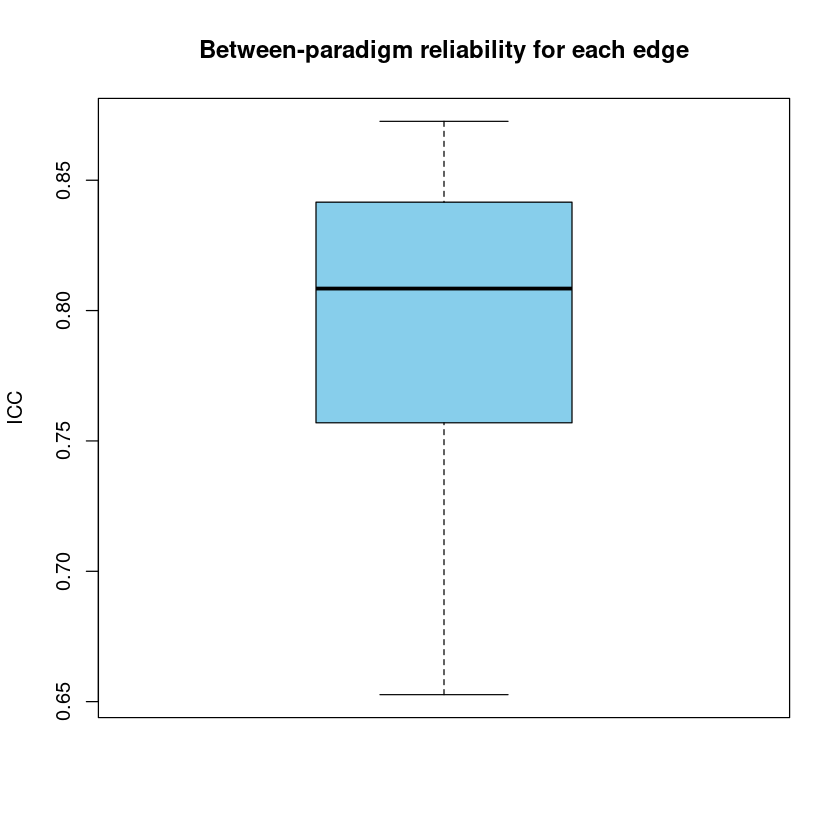

In [20]:
mean_icc <- mean(icc_results$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_results$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_results <- rbind(
    icc_results,
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean"),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median"),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25"),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75")
)

boxplot(icc_results$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")

In [21]:
icc_results

,variability_type,task,scanner,repetition,ICC,summary_statistic
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,within-scanner,rsmovie,prisma,NA,0.8725827,NA
2,between-paradigm,NA,prisma,1,0.6526815,NA
3,between-paradigm,NA,prisma,2,0.7569532,NA
4,between-paradigm,NA,prisma,3,0.7377676,NA
5,between-paradigm,NA,prisma,4,0.8091292,NA
6,between-paradigm,NA,prisma,5,0.8084433,NA
7,between-paradigm,NA,prisma,6,0.7057181,NA
8,between-paradigm,NA,prisma,7,0.8554978,NA
9,between-paradigm,NA,prisma,8,0.8210733,NA


In [24]:
py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'iccparadigm'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

write.table(icc_results, file = py$save_path, sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)
